In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# load data
ir_df = pd.read_csv("../data/oc_2022_november/indreg_2018_2020_megye.csv", sep=";")

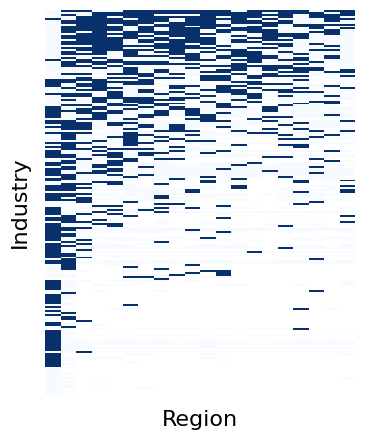

In [18]:
def mcp_matrix(df, key_cols, heatmap, fontsize, ax=None):
    table = df[key_cols]
    table.loc[table["rca18"] >=1, ["rca18"]] = 1
    table.loc[table["rca18"] < 1, ["rca18"]] = 0
    
    table = pd.pivot_table(table,
        values="rca18",
        index=["ind"],
        columns=["reg"],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
    
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Region", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
fig, ax = plt.subplots(1,1, figsize=(4,5))
mcp_matrix(ir_df, key_cols=["reg", "ind", "rca18"], fontsize=16, heatmap=True)

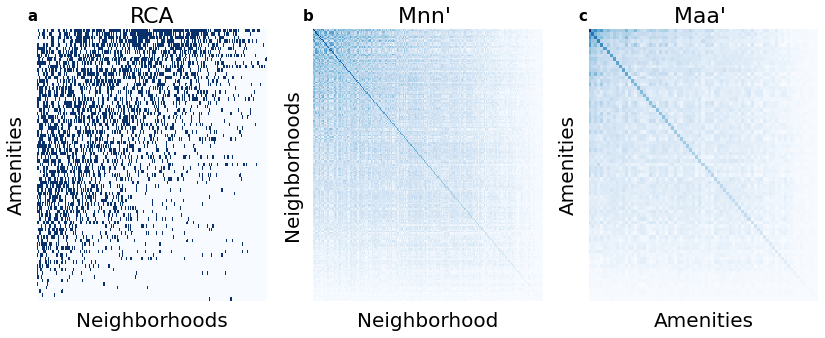

In [22]:
### Figure 3 -- in grid
fig, ax = plt.subplots(1,3, figsize=(14,5))

# a
location_amenity_RCA_matrix(pc.complexity_df, heatmap=True, ax=ax[0])

# c
location_similarity_matrix(pc.complexity_df, heatmap=True, ax=ax[1])

# d
amenity_similarity_matrix(pc.complexity_df, heatmap=True, ax=ax[2])

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.lower(), xy=(0,1), xycoords='axes fraction', xytext=(-10,8), textcoords='offset pixels', weight='bold', size=15)

# plt.savefig('../figures/figure_03.png', density=300, bbox_inches='tight', facecolor="white")
# plt.savefig("../figures/for_manipulation/figure_03.svg")
# plt.rc("pdf", fonttype=42)
# plt.savefig("../figures/for_manipulation/figure_03.pdf", bbox_inches='tight')